# Classification

In this notebook, I train a classifier on the ticket groups defined in `1. Exploration.ipynb`, so that
future tickets can be routed automatically.

## Plan

- Load the exploration artefacts: the ticket groups (`ticket_groups.json`), the cleaned tickets
  (`cleaned_tickets.pkl`) and their `multilingual-e5-large` embeddings, loaded through the same
  hash-keyed cache the exploration notebook uses. The groups are the HDBSCAN clusters *after* label
  spreading reclaimed part of the noise bucket, so `Other` is smaller than the raw noise share.
- Train a multinomial logistic regression on the eight real groups. `Other` is **not** a class: it is
  the HDBSCAN noise bucket - heterogeneous by construction - so nothing coherent can be learned from it.
- Add a rejection rule: when the model is not confident enough, route the ticket to `Other` for a
  human instead of forcing a class. The `Other` tickets are used to calibrate that threshold.
- Train a distance-weighted cosine kNN on the same vectors and compare the two models on both jobs:
  labelling in-domain tickets and rejecting `Other`.
- Save the model, the threshold and an inference function that cleans and embeds a new ticket the
  same way the exploration notebook did (the encoder runs on the GPU when one is available).

## Packages and settings

In [1]:
import hashlib
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score, log_loss

import matplotlib.pyplot as plt

from ticket_cleaning import clean_ticket

G:\Projects\Voll Technical Challenge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 90)

SEED = 42
CLEANED_TICKETS_PATH = Path("dataset/cleaned_tickets.pkl")
TICKET_GROUPS_PATH = Path("dataset/ticket_groups.json")
EMBEDDINGS_DIR = Path("dataset/embeddings")
MODEL_PATH = Path("models/ticket_classifier.joblib")
OTHER_LABEL = "Other"

# Same encoder, prefix and batch size as the exploration notebook: the cache key below depends on them,
# and new tickets must be embedded exactly the same way at inference.
EMBEDDING_MODEL = "intfloat/multilingual-e5-large"
EMBEDDING_PREFIX = "query: "
EMBEDDING_BATCH_SIZE = 16

# The GPU serves the encoder (560M parameters). The classifier itself is scikit-learn on the CPU:
# fitting a logistic regression on a few hundred 1024-d vectors takes well under a second.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))

device: cuda (NVIDIA GeForce RTX 4060 Ti)


## Load the exploration artefacts

`1. Exploration.ipynb` produced two files that describe the same 473 tickets from two angles:

- `cleaned_tickets.pkl` - one row per ticket with the raw and cleaned text, the final `group` (HDBSCAN
  clusters merged into eight groups, then label spreading over the noise bucket) and `group_hdbscan`,
  the assignment before label spreading. The latter is kept to check how the classifier treats the
  reclaimed tickets.
- `ticket_groups.json` - the raw `subject`/`body` of every ticket, keyed by group. This is the
  definition of the classes, so the labels are taken from here and joined back onto the cleaned tickets.

The join is on the raw `(subject, body)` pair, which is unique per ticket. Both files come from the same
run, so the join must be complete and must agree with the pickle's own `group` column.

In [3]:
tickets_df = pd.read_pickle(CLEANED_TICKETS_PATH)
ticket_groups = json.loads(TICKET_GROUPS_PATH.read_text(encoding="utf-8"))

group_lookup = {(t["subject"], t["body"]): group for group, members in ticket_groups.items() for t in members}
assert len(group_lookup) == sum(len(m) for m in ticket_groups.values()), "duplicate (subject, body) in ticket_groups.json"

tickets_df["group"] = [group_lookup.get(key) for key in zip(tickets_df["subject"], tickets_df["body"])]
assert tickets_df["group"].notna().all(), "some cleaned tickets are missing from ticket_groups.json"
assert (tickets_df["group"] == pd.read_pickle(CLEANED_TICKETS_PATH)["group"]).all(), \
    "ticket_groups.json and cleaned_tickets.pkl disagree - re-run the exploration notebook"

y = tickets_df["group"].to_numpy()
# Sorted: scikit-learn orders predict_proba columns by sorted label, and CLASSES must match it.
CLASSES = sorted(g for g in ticket_groups if g != OTHER_LABEL)
in_domain = y != OTHER_LABEL

print(f"{len(tickets_df)} tickets: {in_domain.sum()} in {len(CLASSES)} classes, "
      f"{(~in_domain).sum()} '{OTHER_LABEL}' held out for the rejection rule\n")
print(tickets_df["group"].value_counts().to_string())

473 tickets: 397 in 8 classes, 76 'Other' held out for the rejection rule

group
Hardware (Desktop/Notebook/Tablet)                    86
AWS                                                   77
Other                                                 76
Impressora                                            55
Software (Microsoft, Google, Zoom, Photoshop, ...)    49
Rede                                                  44
Servidor                                              39
Jira                                                  39
Banco de Dados                                         8


### Embeddings

The exploration notebook caches every embedding run under `dataset/embeddings/`, keyed by a hash of the
texts, the model name and the prefix. Reusing the same key here guarantees the vectors correspond to
*exactly* the cleaned text that was clustered: if the cleaning rules change, the key changes and the
tickets are re-encoded (on the GPU) instead of silently reusing stale vectors.

In [4]:
_encoder = None

def get_encoder():
    """Load the sentence-transformers model once per kernel, on the GPU when available."""
    global _encoder
    if _encoder is None:
        _encoder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
    return _encoder


def embed_documents(texts, model_name=EMBEDDING_MODEL, prefix=EMBEDDING_PREFIX,
                    cache_dir=EMBEDDINGS_DIR, batch_size=EMBEDDING_BATCH_SIZE):
    """Same cache contract as the exploration notebook: L2-normalised float32, one row per text."""
    texts = list(texts)
    digest = hashlib.sha1(("\n".join(texts) + model_name + prefix).encode("utf-8")).hexdigest()[:10]
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{model_name.replace('/', '__')}__{len(texts)}docs__{digest}.npy"

    if cache_path.exists():
        vectors = np.load(cache_path)
        print(f"loaded {vectors.shape} from cache -> {cache_path.name}")
        return vectors

    started = time.perf_counter()
    vectors = get_encoder().encode(
        [prefix + t for t in texts], batch_size=batch_size, normalize_embeddings=True,
        convert_to_numpy=True, show_progress_bar=True).astype(np.float32)
    np.save(cache_path, vectors)
    print(f"encoded {vectors.shape} in {time.perf_counter() - started:.0f}s on {DEVICE} -> cached to {cache_path.name}")
    return vectors


X = embed_documents(tickets_df["cleaned_full_text"])
assert X.shape[0] == len(tickets_df)
assert np.allclose(np.linalg.norm(X, axis=1), 1.0, atol=1e-4), "vectors must be unit-norm"

X_in, y_in = X[in_domain], y[in_domain]
X_other = X[~in_domain]
print(f"in-domain {X_in.shape}, Other {X_other.shape}")

loaded (473, 1024) from cache -> intfloat__multilingual-e5-large__473docs__507471ea81.npy
in-domain (397, 1024), Other (76, 1024)


The raw 1024-d vectors are anisotropic (exploration: mean-vector norm 0.94, every pairwise cosine above
0.78), so the classifier pipeline starts by centring them - the same fix PCA applied there. Nothing else
is needed: a linear model absorbs the projection step on its own.

## Multinomial logistic regression

Pipeline: centre the embeddings, then multinomial logistic regression.

- `class_weight="balanced"`: the smallest class (`Banco de Dados`) has 8 tickets, the largest 86.
- Only `C` (inverse regularisation) is tuned, with stratified 5-fold cross-validation.
- Macro-F1 saturates at 1.0 for every `C` (the labels *are* clusters of this space), and log-loss keeps
  improving with `C` because the model just grows more confident. Neither can pick `C`. The rejection
  rule below can: for each `C` the sweep also finds the best confidence threshold and scores how well it
  separates in-domain tickets from `Other`. That balanced rate selects `C`.
- The grid runs past the optimum on purpose: with `C` very large the model is nearly unregularised,
  both populations pile up at probability ~1 and the threshold stops discriminating, so the balanced
  rate must be seen to fall again before the chosen `C` can be trusted.

In [5]:
C_GRID = [1, 3, 10, 30, 100, 300, 1000]
THRESHOLDS = np.round(np.arange(0.30, 1.0001, 0.005), 3)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def make_model(C):
    return make_pipeline(
        StandardScaler(with_std=False),
        LogisticRegression(C=C, class_weight="balanced", max_iter=5000, random_state=SEED))


def rejection_sweep(conf_in, conf_other, thresholds=THRESHOLDS):
    """For each threshold: share of in-domain accepted, share of Other rejected, and their mean."""
    sweep = pd.DataFrame({
        "threshold": thresholds,
        "in-domain accepted": [(conf_in >= t).mean() for t in thresholds],
        "Other rejected": [(conf_other < t).mean() for t in thresholds],
    }).set_index("threshold")
    sweep["balanced"] = (sweep["in-domain accepted"] + sweep["Other rejected"]) / 2
    return sweep


c_sweep = []
for C in C_GRID:
    proba = cross_val_predict(make_model(C), X_in, y_in, cv=cv, method="predict_proba")
    pred = np.array(CLASSES)[proba.argmax(axis=1)]
    conf_other = make_model(C).fit(X_in, y_in).predict_proba(X_other).max(axis=1)
    sweep = rejection_sweep(proba.max(axis=1), conf_other)
    best = sweep["balanced"].idxmax()
    c_sweep.append({"C": C, "macro F1": f1_score(y_in, pred, average="macro"),
                    "log loss": log_loss(y_in, proba, labels=CLASSES),
                    "median conf in-domain": np.median(proba.max(axis=1)),
                    "median conf Other": np.median(conf_other),
                    "best threshold": best, "balanced": sweep.loc[best, "balanced"]})
c_sweep = pd.DataFrame(c_sweep).set_index("C")
print(c_sweep.to_string(float_format=lambda v: f"{v:.3f}"))

BEST_C = float(c_sweep["balanced"].idxmax())
print(f"\nBEST_C = {BEST_C}")

      macro F1  log loss  median conf in-domain  median conf Other  best threshold  balanced
C                                                                                           
1        1.000     1.115                  0.330              0.233           0.300     0.788
3        1.000     0.595                  0.567              0.360           0.480     0.857
10       1.000     0.263                  0.792              0.529           0.710     0.870
30       1.000     0.121                  0.906              0.675           0.835     0.874
100      1.000     0.052                  0.964              0.790           0.930     0.873
300      1.000     0.025                  0.986              0.872           0.965     0.856
1000     1.000     0.012                  0.995              0.931           0.990     0.868

BEST_C = 30.0


Out-of-fold evaluation with the chosen `C`: every ticket is scored by a model that did not see it.

Expect near-perfect scores: the labels *are* clusters of this embedding space, so a linear model
separating them is confirming the clustering, not measuring real-world accuracy. The informative part
is the rejection rule below.

                                                    precision    recall  f1-score   support

                                               AWS      1.000     1.000     1.000        77
                                    Banco de Dados      1.000     1.000     1.000         8
                Hardware (Desktop/Notebook/Tablet)      1.000     1.000     1.000        86
                                        Impressora      1.000     1.000     1.000        55
                                              Jira      1.000     1.000     1.000        39
                                              Rede      1.000     1.000     1.000        44
                                          Servidor      1.000     1.000     1.000        39
Software (Microsoft, Google, Zoom, Photoshop, ...)      1.000     1.000     1.000        49

                                          accuracy                          1.000       397
                                         macro avg      1.000     1.000     1.

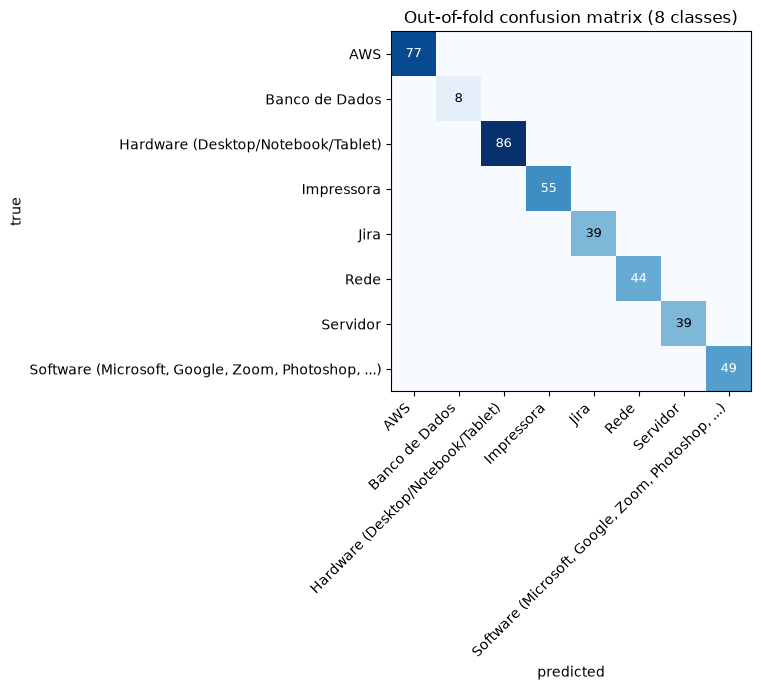

In [6]:
oof_proba = cross_val_predict(make_model(BEST_C), X_in, y_in, cv=cv, method="predict_proba")
oof_pred = np.array(CLASSES)[oof_proba.argmax(axis=1)]

print(classification_report(y_in, oof_pred, labels=CLASSES, digits=3, zero_division=0))

cm = confusion_matrix(y_in, oof_pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set(xlabel="predicted", ylabel="true", title=f"Out-of-fold confusion matrix ({len(CLASSES)} classes)")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
plt.tight_layout()
plt.savefig("images/classification_confusion_matrix.png", dpi=300)
plt.show()

## Rejection rule

A ticket is accepted when the highest class probability reaches a threshold; otherwise it is routed to
`Other` for a human. Two populations decide the threshold:

- **In-domain** tickets, scored out-of-fold: their max-probability should stay *above* the threshold
  (coverage).
- **`Other`** tickets, scored by a model trained on all in-domain data (they were never seen): their
  max-probability should fall *below* it (rejection).

The threshold maximises the balanced rate `(in-domain accepted + Other rejected) / 2`, so neither side
dominates. The two distributions overlap - some noise tickets genuinely read like a class - so no
threshold separates them fully; the plot shows the trade-off being made.

REJECT_THRESHOLD = 0.835
  in-domain accepted   86.6%   accuracy on accepted 100.0%
  Other rejected       88.2%

max-probability: in-domain median 0.91, Other median 0.67


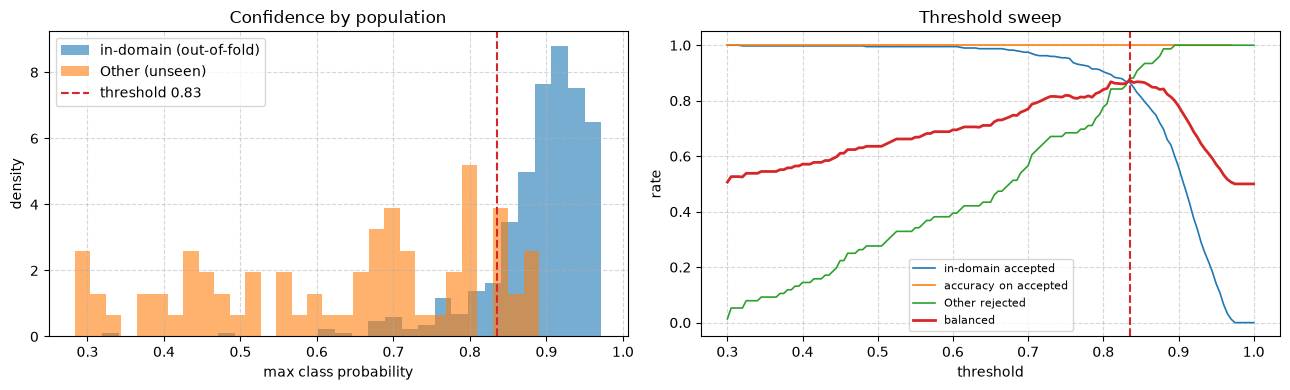

In [7]:
full_model = make_model(BEST_C).fit(X_in, y_in)
assert list(full_model.classes_) == CLASSES

conf_in = oof_proba.max(axis=1)
conf_other = full_model.predict_proba(X_other).max(axis=1)

sweep = rejection_sweep(conf_in, conf_other)
sweep["accuracy on accepted"] = [
    (oof_pred[conf_in >= t] == y_in[conf_in >= t]).mean() if (conf_in >= t).any() else np.nan
    for t in sweep.index]

REJECT_THRESHOLD = float(sweep["balanced"].idxmax())
chosen = sweep.loc[REJECT_THRESHOLD]
print(f"REJECT_THRESHOLD = {REJECT_THRESHOLD:.3f}")
print(f"  in-domain accepted   {chosen['in-domain accepted']:.1%}   "
      f"accuracy on accepted {chosen['accuracy on accepted']:.1%}")
print(f"  Other rejected       {chosen['Other rejected']:.1%}")
print(f"\nmax-probability: in-domain median {np.median(conf_in):.2f}, Other median {np.median(conf_other):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(conf_in, bins=30, alpha=.6, density=True, label="in-domain (out-of-fold)")
axes[0].hist(conf_other, bins=30, alpha=.6, density=True, label="Other (unseen)")
axes[0].axvline(REJECT_THRESHOLD, ls="--", color="tab:red", label=f"threshold {REJECT_THRESHOLD:.2f}")
axes[0].set(xlabel="max class probability", ylabel="density", title="Confidence by population")
axes[0].legend()
for col in ["in-domain accepted", "accuracy on accepted", "Other rejected", "balanced"]:
    axes[1].plot(sweep.index, sweep[col], label=col, lw=2 if col == "balanced" else 1.2)
axes[1].axvline(REJECT_THRESHOLD, ls="--", color="tab:red")
axes[1].set(xlabel="threshold", ylabel="rate", title="Threshold sweep")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(linestyle="--", alpha=.5)
plt.tight_layout()
plt.savefig("images/classification_rejection_threshold.png", dpi=300)
plt.show()

End-to-end view: out-of-fold predictions **with** the rejection rule, on every ticket. The `Other`
column now counts a genuine outcome (sent to a human), not a learned class.

In [8]:
def apply_rejection(proba, threshold=None):
    threshold = REJECT_THRESHOLD if threshold is None else threshold
    labels = np.array(CLASSES)[proba.argmax(axis=1)].astype(object)
    labels[proba.max(axis=1) < threshold] = OTHER_LABEL
    return labels


pred_all = np.empty(len(tickets_df), dtype=object)
pred_all[in_domain] = apply_rejection(oof_proba)
pred_all[~in_domain] = apply_rejection(full_model.predict_proba(X_other))

ALL_LABELS = CLASSES + [OTHER_LABEL]
print(classification_report(y, pred_all, labels=ALL_LABELS, digits=3, zero_division=0))

routing = pd.crosstab(pd.Series(y, name="true"), pd.Series(pred_all, name="predicted")).reindex(
    index=ALL_LABELS, columns=ALL_LABELS, fill_value=0)
routing

                                                    precision    recall  f1-score   support

                                               AWS      1.000     0.922     0.959        77
                                    Banco de Dados      1.000     0.750     0.857         8
                Hardware (Desktop/Notebook/Tablet)      1.000     0.837     0.911        86
                                        Impressora      0.981     0.945     0.963        55
                                              Jira      0.973     0.923     0.947        39
                                              Rede      1.000     0.977     0.989        44
                                          Servidor      0.909     0.769     0.833        39
Software (Microsoft, Google, Zoom, Photoshop, ...)      0.895     0.694     0.782        49
                                             Other      0.558     0.882     0.684        76

                                          accuracy                          0.

predicted,AWS,Banco de Dados,Hardware (Desktop/Notebook/Tablet),Impressora,Jira,Rede,Servidor,"Software (Microsoft, Google, Zoom, Photoshop, ...)",Other
true,,,,,,,,,
AWS,71,0,0,0,0,0,0,0,6
Banco de Dados,0,6,0,0,0,0,0,0,2
Hardware (Desktop/Notebook/Tablet),0,0,72,0,0,0,0,0,14
Impressora,0,0,0,52,0,0,0,0,3
Jira,0,0,0,0,36,0,0,0,3
Rede,0,0,0,0,0,43,0,0,1
Servidor,0,0,0,0,0,0,30,0,9
"Software (Microsoft, Google, Zoom, Photoshop, ...)",0,0,0,0,0,0,0,34,15
Other,0,0,0,1,1,0,3,4,67


### Where do the rejected in-domain tickets come from?

Label spreading admitted a noise ticket when its cosine to the nearest member of the winning group was at
least 0.45 - well below what cluster members share with each other (median 0.79). Those tickets sit at
the fringe of their group by construction, so the question is whether the rejection rule, calibrated on
all in-domain tickets, keeps them or sends them back. `group_hdbscan` tells the two populations apart.

In [9]:
# Origin of every in-domain ticket: HDBSCAN cluster member, or reclaimed from the noise bucket by label spreading.
reclaimed = (tickets_df["group_hdbscan"].to_numpy() == OTHER_LABEL)[in_domain]
origin = np.where(reclaimed, "reclaimed by label spreading", "HDBSCAN cluster member")
rejected = conf_in < REJECT_THRESHOLD

by_origin = pd.DataFrame({"origin": origin, "rejected": rejected, "confidence": conf_in}).groupby("origin").agg(
    tickets=("rejected", "size"), rejected=("rejected", "sum"), median_confidence=("confidence", "median"))
by_origin["rejected %"] = by_origin["rejected"] / by_origin["tickets"] * 100
print(by_origin.round({"median_confidence": 2, "rejected %": 1}).to_string())

# Does the threshold depend on the reclaimed tickets? Re-calibrate coverage on the cluster members alone.
core_sweep = rejection_sweep(conf_in[~reclaimed], conf_other)
print(f"\nthreshold calibrated on cluster members only: {core_sweep['balanced'].idxmax():.3f} "
      f"(notebook: {REJECT_THRESHOLD:.3f})")

per_group = (pd.DataFrame({"group": y_in, "origin": origin, "rejected": rejected})
             .groupby(["group", "origin"])["rejected"].agg(rejected="sum", tickets="size")
             .unstack("origin", fill_value=0))
per_group

                              tickets  rejected  median_confidence  rejected %
origin                                                                        
HDBSCAN cluster member            340        26               0.91         7.6
reclaimed by label spreading       57        27               0.84        47.4

threshold calibrated on cluster members only: 0.835 (notebook: 0.835)


rejected                                             tickets                             
origin                                             HDBSCAN cluster member reclaimed by label spreading HDBSCAN cluster member reclaimed by label spreading
group                                                                                                                                                     
AWS                                                                     3                            3                     59                           18
Banco de Dados                                                          1                            1                      7                            1
Hardware (Desktop/Notebook/Tablet)                                     10                            4                     80                            6
Impressora                                                              0                            3                     50                            5
Jira                                                                    1                            2                     37                            2
Rede                                                                    1                            0                     44                            0
Servidor                                                                1                            8                     24                           15
Software (Microsoft, Google, Zoom, Photoshop, ...)                      9                            6                     39                           10

The two populations behave very differently: the rule rejects about half of the reclaimed tickets and
under a tenth of the original cluster members, and the threshold itself does not move when the reclaimed
tickets are left out of the calibration - 0.835 either way - so this is not an artefact of where the
threshold sits.

This is not a contradiction between the two steps. Label spreading answers *"which group is this ticket
closest to?"* and hands every noise ticket the best available answer; the rejection rule answers *"is the
model sure enough to route this without a human?"*. On the fringe those answers differ, and the 27
tickets where they do are precisely the ones a reviewer should confirm: once confirmed they become the
training examples that widen the class, and the rule will accept their neighbours next round. `Servidor`
and `Software` carry most of them.

## Distance-weighted kNN (cosine)

A second model on the same vectors, chosen for being the opposite of the first: non-parametric, no
training step, and a decision that is easy to explain (*"the closest known tickets are Rede tickets"*).
The labels came out of a density clustering, so a neighbourhood vote is a natural fit.

- Cosine distance on the unit-norm vectors; `weights="distance"` so a neighbour's vote counts `1 / d`,
  letting a few very close tickets outweigh many farther ones.
- Only `k` is tuned, with the same 5-fold out-of-fold protocol as `C`. The sweep runs on raw and on
  centred vectors: centring helped the linear model, and kNN only ranks neighbours, so it need not help
  here.
- The rejection rule is evaluated with the model's own probability, the distance-weighted vote share,
  exactly as for the logistic regression.

In [10]:
K_GRID = [1, 3, 5, 7, 10, 15, 20, 30, 50]


def make_knn(k, centred=False):
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance", metric="cosine")
    return make_pipeline(StandardScaler(with_std=False), knn) if centred else make_pipeline(knn)


k_sweep = []
for centred in (False, True):
    for k in K_GRID:
        proba = cross_val_predict(make_knn(k, centred), X_in, y_in, cv=cv, method="predict_proba")
        pred = np.array(CLASSES)[proba.argmax(axis=1)]
        conf_other_k = make_knn(k, centred).fit(X_in, y_in).predict_proba(X_other).max(axis=1)
        sweep_k = rejection_sweep(proba.max(axis=1), conf_other_k)
        best = sweep_k["balanced"].idxmax()
        k_sweep.append({"centred": centred, "k": k, "macro F1": f1_score(y_in, pred, average="macro"),
                        "log loss": log_loss(y_in, proba, labels=CLASSES),
                        "vote share == 1: in-domain": (proba.max(axis=1) >= 0.9999).mean(),
                        "vote share == 1: Other": (conf_other_k >= 0.9999).mean(),
                        "best threshold": best, "balanced": sweep_k.loc[best, "balanced"]})
k_sweep = pd.DataFrame(k_sweep).set_index(["centred", "k"])
print(k_sweep.to_string(float_format=lambda v: f"{v:.3f}"))

# k: the largest value that keeps out-of-fold macro-F1 at its maximum. More neighbours make the vote
# more stable; past that point the neighbourhood starts crossing class borders.
raw_sweep = k_sweep.loc[False]
KNN_K = int(raw_sweep.index[raw_sweep["macro F1"] == raw_sweep["macro F1"].max()].max())
print(f"\nKNN_K = {KNN_K}")

            macro F1  log loss  vote share == 1: in-domain  vote share == 1: Other  best threshold  balanced
centred k                                                                                                   
False   1      1.000     0.000                       1.000                   1.000           0.300     0.500
        3      1.000     0.002                       0.995                   0.592           0.700     0.703
        5      1.000     0.005                       0.977                   0.329           0.840     0.828
        7      1.000     0.012                       0.927                   0.263           0.880     0.844
        10     0.991     0.028                       0.872                   0.171           0.915     0.867
        15     0.981     0.058                       0.773                   0.092           0.940     0.854
        20     0.965     0.091                       0.652                   0.066           0.915     0.848
        30     0.90

Two things stand out in the sweep.

- **Labelling** is as easy for kNN as for the linear model: macro-F1 is perfect for every `k` up to
  7 on raw vectors, and centring does not help (it never improves the rejection score, and lowers it
  for every `k` past 1), so the model stays on the raw cosine geometry.
- **The vote share is a poor confidence.** Distance weighting sets the *ranking* of neighbours, but once
  every neighbour agrees the share is exactly 1.0 whether those neighbours are at cosine 0.99 or 0.85.
  The two `== 1` columns show it: at `k = 7`, 93% of in-domain tickets *and* 26% of `Other` tickets
  score 1.0, so no threshold can tell them apart. Larger `k` spreads the share out, but only by pulling
  in neighbours from other classes, which is what starts costing macro-F1.

The information the vote share throws away is the distance itself. The natural kNN confidence is the
cosine similarity to the **nearest** known ticket: it does not depend on `k`, it is what a human would
check (*"is there a ticket like this one?"*), and it is what the next cell compares against the vote
share and against the logistic regression's probability.

In [11]:
def knn_scores(knn, X_query):
    """Predicted label, distance-weighted vote share, and cosine similarity to the nearest neighbour."""
    proba = knn.predict_proba(X_query)
    # `knn` is a pipeline: run any preprocessing steps, then query the estimator itself.
    nn_dist, _ = knn[-1].kneighbors(knn[:-1].transform(X_query) if len(knn) > 1 else X_query, n_neighbors=1)
    return np.array(CLASSES)[proba.argmax(axis=1)], proba.max(axis=1), 1.0 - nn_dist[:, 0]


knn_oof_pred = np.empty(len(y_in), dtype=object)
knn_oof_share = np.zeros(len(y_in))
knn_oof_nn_sim = np.zeros(len(y_in))
for train_idx, test_idx in cv.split(X_in, y_in):
    fold_knn = make_knn(KNN_K).fit(X_in[train_idx], y_in[train_idx])
    knn_oof_pred[test_idx], knn_oof_share[test_idx], knn_oof_nn_sim[test_idx] = knn_scores(fold_knn, X_in[test_idx])

knn_model = make_knn(KNN_K).fit(X_in, y_in)
assert list(knn_model.classes_) == CLASSES
knn_other_pred, knn_other_share, knn_other_nn_sim = knn_scores(knn_model, X_other)

print(classification_report(y_in, knn_oof_pred, labels=CLASSES, digits=3, zero_division=0))

                                                    precision    recall  f1-score   support

                                               AWS      1.000     1.000     1.000        77
                                    Banco de Dados      1.000     1.000     1.000         8
                Hardware (Desktop/Notebook/Tablet)      1.000     1.000     1.000        86
                                        Impressora      1.000     1.000     1.000        55
                                              Jira      1.000     1.000     1.000        39
                                              Rede      1.000     1.000     1.000        44
                                          Servidor      1.000     1.000     1.000        39
Software (Microsoft, Google, Zoom, Photoshop, ...)      1.000     1.000     1.000        49

                                          accuracy                          1.000       397
                                         macro avg      1.000     1.000     1.

## Model comparison

Same protocol for every row: in-domain tickets scored out-of-fold, `Other` tickets scored by the model
fitted on all in-domain data, threshold chosen by the balanced rate. The kNN appears twice, once per
confidence signal.

                                       OOF macro F1  threshold  in-domain accepted  accuracy on accepted  Other rejected  balanced
model                                                                                                                             
Logistic regression - max probability         1.000      0.835               0.866                 1.000           0.882     0.874
kNN (k=7) - vote share                        1.000      0.880               0.965                 1.000           0.724     0.844
kNN (k=7) - 1-NN cosine similarity            1.000      0.945               0.924                 1.000           0.816     0.870


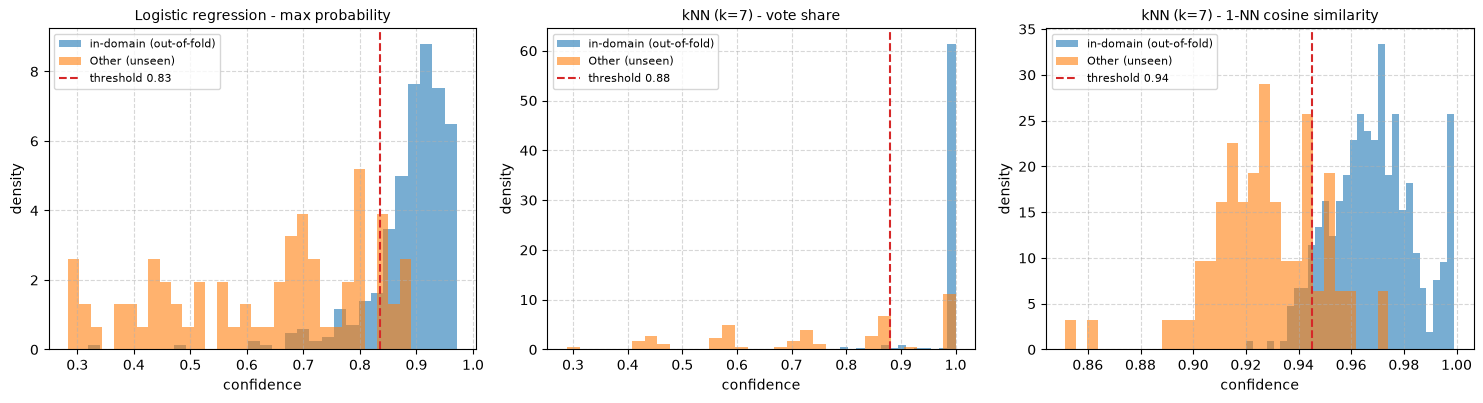

In [12]:
candidates = {
    "Logistic regression - max probability": (oof_pred, conf_in, conf_other),
    f"kNN (k={KNN_K}) - vote share": (knn_oof_pred, knn_oof_share, knn_other_share),
    f"kNN (k={KNN_K}) - 1-NN cosine similarity": (knn_oof_pred, knn_oof_nn_sim, knn_other_nn_sim),
}

comparison = []
for name, (pred, c_in, c_other) in candidates.items():
    sweep_c = rejection_sweep(c_in, c_other)
    t = sweep_c["balanced"].idxmax()
    comparison.append({"model": name,
                       "OOF macro F1": f1_score(y_in, pred, average="macro"),
                       "threshold": t,
                       "in-domain accepted": sweep_c.loc[t, "in-domain accepted"],
                       "accuracy on accepted": (pred[c_in >= t] == y_in[c_in >= t]).mean(),
                       "Other rejected": sweep_c.loc[t, "Other rejected"],
                       "balanced": sweep_c.loc[t, "balanced"]})
comparison = pd.DataFrame(comparison).set_index("model")
print(comparison.to_string(float_format=lambda v: f"{v:.3f}"))

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
axes = axes.ravel()
for ax in axes[len(candidates):]:
    ax.set_visible(False)
for ax, (name, (_, c_in, c_other)) in zip(axes, candidates.items()):
    ax.hist(c_in, bins=30, alpha=.6, density=True, label="in-domain (out-of-fold)")
    ax.hist(c_other, bins=30, alpha=.6, density=True, label="Other (unseen)")
    ax.axvline(comparison.loc[name, "threshold"], ls="--", color="tab:red",
               label=f"threshold {comparison.loc[name, 'threshold']:.2f}")
    ax.set(title=name, xlabel="confidence", ylabel="density")
    ax.title.set_fontsize(10)
    ax.grid(linestyle="--", alpha=.5)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("images/classification_model_comparison.png", dpi=300)
plt.show()

**Verdict.** On labelling, the two models tie: both reproduce the eight groups perfectly out-of-fold, as
expected for cluster-derived labels. The difference is entirely in the rejection rule.

- The kNN's own probability is not usable as a confidence: the vote share saturates and its balanced
  rate (0.844) trails the logistic regression (0.874) - it accepts more in-domain tickets but lets 28%
  of `Other` through.
- Given a distance-aware confidence - the similarity to the nearest known ticket - the kNN gets close to
  the logistic regression (0.870), which shows the rejection is mostly a property of the embedding space
  rather than of the classifier. The logistic regression still edges it: its probability combines evidence from
  the whole class, while a single nearest neighbour is one ticket, and the noise bucket contains tickets
  that happen to sit right next to one.

The logistic regression is the model that gets saved. The kNN earns its place as a check: it confirms
the classes without any training, and its 1-NN similarity is the reading a reviewer can verify by
looking at one ticket.

## Save the model and inference function

The bundle carries everything inference needs: the encoder name and prefix, the class list, the fitted
model and the threshold. `classify_ticket` is the single entry point for new tickets: it cleans the text
with `ticket_cleaning.clean_ticket`, embeds it with the same encoder (on the GPU) and applies the
rejection rule.

In [13]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "embedding_model": EMBEDDING_MODEL,
    "embedding_prefix": EMBEDDING_PREFIX,
    "classes": CLASSES,
    "other_label": OTHER_LABEL,
    "reject_threshold": REJECT_THRESHOLD,
    "model": full_model,
}, MODEL_PATH)
print(f"saved -> {MODEL_PATH}")


def classify_ticket(subject, body, threshold=None):
    """Route one ticket: returns (label, confidence). Label is Other when confidence < threshold."""
    threshold = REJECT_THRESHOLD if threshold is None else threshold
    text = clean_ticket(subject, body)
    vector = get_encoder().encode([EMBEDDING_PREFIX + text], normalize_embeddings=True)
    proba = full_model.predict_proba(vector)[0]
    label, confidence = CLASSES[proba.argmax()], float(proba.max())
    return (label if confidence >= threshold else OTHER_LABEL), confidence


examples = [
    ("Roteador reiniciando", "O ISR4331 reinicia sozinho várias vezes por dia e derruba a rede do escritório."),
    ("Fatura AWS", "Recebi uma cobrança inesperada na conta AWS deste mês e preciso de esclarecimento."),
    ("Impressora não imprime", "A DeskJet não aparece mais no Wi-Fi depois que troquei o roteador."),
    ("Erro no Jira", "Não consigo anexar arquivos aos tickets desde a atualização para a versão 8.20."),
    ("Pedido de orçamento", "Gostaria de um orçamento para 20 licenças de um software de RH."),
]
started = time.perf_counter()
for subject, body in examples:
    label, confidence = classify_ticket(subject, body)
    print(f"{confidence:.2f}  {label:<52} {subject}")
print(f"\n{len(examples)} tickets classified in {time.perf_counter() - started:.1f}s on {DEVICE} (includes model load)")

saved -> models\ticket_classifier.joblib


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:  10%|▉         | 39/391 [00:00<00:00, 361.14it/s]

Loading weights:  19%|█▉        | 76/391 [00:00<00:01, 261.57it/s]

Loading weights:  27%|██▋       | 104/391 [00:00<00:01, 260.11it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 826.23it/s]

0.87  Rede                                                 Roteador reiniciando
0.90  AWS                                                  Fatura AWS
0.79  Other                                                Impressora não imprime
0.97  Jira                                                 Erro no Jira
0.40  Other                                                Pedido de orçamento

5 tickets classified in 7.1s on cuda (includes model load)


## Outputs

| Artefact | Content |
|---|---|
| `models/ticket_classifier.joblib` | encoder name + prefix, class list, fitted pipeline (centring + multinomial logistic regression), rejection threshold |
| `classify_ticket(subject, body)` | `ticket_cleaning.clean_ticket` -> embedding (GPU) -> probability -> label or `Other` |
| `images/classification_confusion_matrix.png`, `images/classification_rejection_threshold.png`, `images/classification_model_comparison.png` | evaluation figures |

The classes are pseudo-labels from clustering, so the reported scores measure agreement with the
clustering, not with a human ground truth. The `Other` route is where that gap gets closed: the tickets
it collects are the ones worth a human's label, and they feed the next training round.

Read the routing table by row:

- Among the in-domain groups, the broad `Software` group loses the most tickets to `Other` (15 of 49):
  it merges several HDBSCAN clusters, so its tickets sit farther from the class centre. `Servidor`
  (9 of 39) and `Hardware` (14 of 86) follow; `Banco de Dados` (2 of 8) is simply thin. The origin
  split above explains most of it: in `Servidor` and `Software`, the rejected tickets are mainly the
  ones label spreading reclaimed. Those rows are the first candidates for a human labelling pass.
- In the `Other` row, 9 of 76 noise tickets are still accepted: two Office 365 tickets and two billing
  ones as `Software`, three server-downtime / configuration requests as `Servidor`, an Epson EcoTank as
  `Impressora`. These are the "near-miss band" the exploration notebook left outside the anchor gate;
  the classifier would take most of them, and a reviewer would probably agree. Confirming them is the
  cheapest way to grow those classes.

Overall, label spreading and the rejection rule agree on the core of every class and disagree only on
its fringe, which is where a human should be looking anyway.